### This notebook extract newly generated molecules after the DORAnet run: 

In [109]:
import os
import io
import re
import math
import json
import glob
import base64
from io import BytesIO
from pathlib import Path
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Draw, QED, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from PIL import Image, ImageDraw, ImageFont
from IPython.display import HTML, display

RDLogger.DisableLog('rdApp.*')

from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

In [95]:
fileNamePrefix = "basidalinPrecursor_gen2"

In [96]:
def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

### Discover All Starter Directories

In [97]:
doranetOutputDir = "doranet_output"
doranet_generations = 2

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [98]:
# Automatically find all starter directories (exclude files)
allStarterDirPaths = sorted([
    p for p in glob.glob(os.path.join(doranetOutputDir, "starter_*"))
    if os.path.isdir(p)
])

print(f"Found {len(allStarterDirPaths)} starter directories")

# Find the molecules CSV file inside each directory
discoveredCsvFiles = []
directoriesWithMissingCsv = []

for starterDirPath in allStarterDirPaths:
    dirName = os.path.basename(starterDirPath)

    # Expected CSV file name matches directory name
    expectedCsvPath = os.path.join(starterDirPath, f"{dirName}_molecules.csv")

    if os.path.exists(expectedCsvPath):
        discoveredCsvFiles.append({
            'dirName': dirName,
            'dirPath': starterDirPath,
            'csvPath': expectedCsvPath,
            'starterNum': int(dirName.replace('starter_', ''))
        })
    else:
        # Try to find any molecules CSV in the directory as fallback
        fallbackCsvPaths = glob.glob(os.path.join(starterDirPath, "*_molecules.csv"))
        if fallbackCsvPaths:
            discoveredCsvFiles.append({
                'dirName': dirName,
                'dirPath': starterDirPath,
                'csvPath': fallbackCsvPaths[0],
                'starterNum': int(dirName.replace('starter_', ''))
            })
        else:
            directoriesWithMissingCsv.append(dirName)

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")
if directoriesWithMissingCsv:
    print(f"Missing CSV in {len(directoriesWithMissingCsv)} directories: "
          f"{directoriesWithMissingCsv[:10]}...")

Found 2054 starter directories
Found 2054 CSV files containing DORAnet generated molecules


### Extract the `DORAnet` starter molecule

In [99]:
user_starters = set()
starterReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        # Read only the SMILES and Is_Starter columns to save memory
        tempDF = pd.read_csv(
            fileInfo['csvPath'],
            usecols=['SMILES', 'Is_Starter']
        )
        starterSmiles = (
            tempDF[tempDF['Is_Starter'] == True]['SMILES']
            .dropna()
            .tolist()
        )
        user_starters.update(starterSmiles)

    except Exception as e:
        starterReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

if len(user_starters) == 0:
    raise ValueError("No starter molecules found across any CSV files!")

print(f"Number of unique starter molecules found: {len(user_starters)}")

Number of unique starter molecules found: 2054


### Read `reaction_strings` from the `DORAnet` generated `json` file

In [100]:
allStarterDirPaths = sorted([
    p for p in glob.glob(os.path.join(doranetOutputDir, "starter_*"))
    if os.path.isdir(p)
])
print(f"Found {len(allStarterDirPaths)} starter directories")

discoveredJsonFiles        = []
directoriesWithMissingJson = []

for starterDirPath in allStarterDirPaths:
    dirName          = os.path.basename(starterDirPath)
    expectedJsonPath = os.path.join(starterDirPath, f"{dirName}_network_pretreated.json")

    if os.path.exists(expectedJsonPath):
        discoveredJsonFiles.append({
            "dirName"   : dirName,
            "dirPath"   : starterDirPath,
            "jsonPath"  : expectedJsonPath,
            "starterNum": int(dirName.replace("starter_", "")),
        })
    else:
        fallbackJsonPaths = glob.glob(os.path.join(starterDirPath, "*_network_pretreated.json"))
        if fallbackJsonPaths:
            discoveredJsonFiles.append({
                "dirName"   : dirName,
                "dirPath"   : starterDirPath,
                "jsonPath"  : fallbackJsonPaths[0],
                "starterNum": int(dirName.replace("starter_", "")),
            })
        else:
            directoriesWithMissingJson.append(dirName)

discoveredJsonFiles.sort(key=lambda x: x["starterNum"])

print(f"Found {len(discoveredJsonFiles)} JSON files")
if directoriesWithMissingJson:
    print(f"Missing JSON in {len(directoriesWithMissingJson)} directories: "
          f"{directoriesWithMissingJson[:10]}")

for fileInfo in discoveredJsonFiles[:3]:
    print(f"  {fileInfo['dirName']} -> {os.path.basename(fileInfo['jsonPath'])}")
if len(discoveredJsonFiles) > 3:
    print(f"  ... and {len(discoveredJsonFiles) - 3} more")


def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString) if hasattr(pd, "isna") else moleculeString is None:
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]


reactionRecords = []
jsonReadErrors  = []

for fileInfo in discoveredJsonFiles:
    try:
        with open(fileInfo["jsonPath"], "r", encoding="utf-8") as f:
            reactionList = json.load(f)

        for rxn in reactionList:
            parts = str(rxn).split(">")
            if len(parts) != 4:
                continue

            reactants, ruleName, metaBlock, products = parts
            metaParts = (metaBlock.split("$") + [None, None, None, None])[:4]
            thermo, reactantStoich, productStoich, reactionType = metaParts

            reactantMols = splitMoleculeString(reactants.strip())
            productMols  = splitMoleculeString(products.strip())

            reactionRecords.append({
                "reactants"            : reactants.strip(),
                "products"             : products.strip(),
                "reactionString"       : f"{reactants.strip()} >> {products.strip()}",
                "ruleName"             : ruleName.strip(),
                "thermo"               : thermo,
                "reactantStoich"       : reactantStoich,
                "productStoich"        : productStoich,
                "reactionType"         : reactionType,
                "numReactantMolecules" : len(reactantMols),
                "numProductMolecules"  : len(productMols),
                "sourceStarterNum"     : fileInfo["starterNum"],
                "sourceDirectory"      : fileInfo["dirName"],
            })

    except Exception as e:
        jsonReadErrors.append({
            "dirName" : fileInfo["dirName"],
            "jsonPath": fileInfo["jsonPath"],
            "error"   : str(e),
        })
        print(f"  ERROR reading {fileInfo['dirName']}: {e}")

if not reactionRecords:
    raise RuntimeError("No reaction records loaded — check discoveredJsonFiles and JSON format.")

reactionDF = pd.DataFrame(reactionRecords).reset_index(drop=True)

allReactantMols = reactionDF["reactants"].apply(splitMoleculeString).explode()
allProductMols  = reactionDF["products"].apply(splitMoleculeString).explode()

print(f"JSON files read successfully         : {len(discoveredJsonFiles) - len(jsonReadErrors)}")
print(f"JSON files failed                    : {len(jsonReadErrors)}")
print(f"Total reactions                      : {len(reactionDF):,}")
print(f"Unique reactant strings              : {reactionDF['reactants'].nunique():,}")
print(f"Unique product strings               : {reactionDF['products'].nunique():,}")
print(f"Unique individual reactant molecules : {allReactantMols.nunique():,}")
print(f"Unique individual product molecules  : {allProductMols.nunique():,}")
print(f"Unique reaction rules                : {reactionDF['ruleName'].nunique():,}")
print(f"Unique source directories            : {reactionDF['sourceDirectory'].nunique():,}")
print(f"Reaction type counts:")
print(reactionDF["reactionType"].value_counts(dropna=False).to_string())

if jsonReadErrors:
    print(f"\nFailed files:")
    for err in jsonReadErrors:
        print(f"  {err['dirName']}: {err['error']}")

reactionDF.to_csv("reactionDF.csv", index=False)
print("\nSaved to: reactionDF.csv")

reactionDF

Found 2054 starter directories
Found 2054 JSON files
  starter_00000 -> starter_00000_network_pretreated.json
  starter_00001 -> starter_00001_network_pretreated.json
  starter_00002 -> starter_00002_network_pretreated.json
  ... and 2051 more
JSON files read successfully         : 2054
JSON files failed                    : 0
Total reactions                      : 2,022,023
Unique reactant strings              : 261,772
Unique product strings               : 1,134,192
Unique individual reactant molecules : 30,356
Unique individual product molecules  : 650,848
Unique reaction rules                : 476
Unique source directories            : 1,489
Reaction type counts:
reactionType
Enzymatic    2022023

Saved to: reactionDF.csv


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,sourceStarterNum,sourceDirectory
0,CCC=C(O)[C@H](O)[C@H](C)C(=O)O,C[C@@H]1C(O)OCCC=C(O)[C@@H]1O,CCC=C(O)[C@H](O)[C@H](C)C(=O)O >> C[C@@H]1C(O)...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,0,starter_00000
1,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,CCC(O)=C1OC(OC)[C@@H](C)[C@H]1O.Nc1ncnc2c1ncn2...,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,rule0011_51,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,0,starter_00000
2,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,CCC(C)=C1OC(=O)[C@@H](C)[C@]1(C)O.Nc1ncnc2c1nc...,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,rule0043_12,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,0,starter_00000
3,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl,CCC(C(=O)Cl)=C1OC(=O)[C@@H](C)[C@H]1O.O,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl >> CCC...,rule0183_6,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,0,starter_00000
4,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O,CC(CC(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O >> CC(CC(...,rule0023_17,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1,0,starter_00000
...,...,...,...,...,...,...,...,...,...,...,...,...
2022018,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O,C[C@](O)(C=O)C=C1C=C(O)C(O)O1,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O >> C[C@](O)(C=...,rule0070_6,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1,2053,starter_02053
2022019,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O,C[C@H](C=C1C=C(O)C(=O)O1)CNC(O)[C@H](C)N.N,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O >> ...,rule0056_18,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,2053,starter_02053
2022020,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN,CC(N)C(=O)NC[C@H](C)C=C1C=C(O)C(=O)O1,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN >> CC(N)C(...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,2053,starter_02053
2022021,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,CNC(=O)[C@@H](N)C[C@H](C)C1OC12C=C(O)C(=O)O2.N...,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,rule0077_4,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,2053,starter_02053


### Identify `generated` compounds with `substructure` match with `starter` compound

In [92]:
DORAnet_CoFactors = "/users/sghosh6/DTRA_project/MACAW/doranet/scripts/doranet_all_cofactors.tsv"

_cofactorTable = pd.read_csv(DORAnet_CoFactors, sep="\t")
_cofactorTable.columns = [col.lstrip("#").strip() for col in _cofactorTable.columns]

COFACTOR_SMILES = [
    Chem.MolToSmiles(mol)
    for smi in _cofactorTable["SMILES"].dropna()
    if (mol := Chem.MolFromSmiles(str(smi))) is not None
]
print(f"{len(COFACTOR_SMILES)} Co-factors for enzymatic reactions loaded from DORAnet database.")

46 Co-factors for enzymatic reactions loaded from DORAnet database.


### `Method-2`: 

In [101]:
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
import base64
from io import BytesIO
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors, Draw
from IPython.display import HTML, display

fpRadius, fpBits = 2, 2048

# Lipinski rule of five: 0 = compound must satisfy all four criteria;
# set to 1 for the classic "no more than one violation" form.
lipinskiMaxViolations = 0

physicochemicalCutoffs = {
    "mwMax"  : 700.0,
    "tpsaMax": 200.0,
    "hbdMax" : 7,
    "qedMin" : 0.10,
}


def morganFp(mol):
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, fpRadius, nBits=fpBits) if mol is not None else None


def buildCofactorExclusionSet(rawSmilesList):
    exclusionSet = set()
    for smi in rawSmilesList:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            exclusionSet.add(Chem.MolToSmiles(mol))
        else:
            print(f"  Warning: could not parse cofactor SMILES: {smi}")
    print(f"Cofactor exclusion set built: {len(exclusionSet)} entries resolved.")
    return exclusionSet


def isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, cutoffs):
    if mol is None:
        return True
    if canonSmi in cofactorExclusionSet:
        return True
    if Descriptors.MolWt(mol)           > cutoffs["mwMax"]:
        return True
    if rdMolDescriptors.CalcTPSA(mol)   > cutoffs["tpsaMax"]:
        return True
    if rdMolDescriptors.CalcNumHBD(mol) > cutoffs["hbdMax"]:
        return True
    return QED.qed(mol) < cutoffs["qedMin"]


def lipinskiViolationCount(mol):
    if mol is None:
        return None
    violations = 0
    if Descriptors.MolWt(mol)           > 500:
        violations += 1
    if Descriptors.MolLogP(mol)         > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBD(mol) > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBA(mol) > 10:
        violations += 1
    return violations


def passesLipinski(canonSmi, maxViolations):
    violations = lipinskiViolationCount(Chem.MolFromSmiles(str(canonSmi)))
    return violations is not None and violations <= maxViolations


def preservesStarterScaffold(compoundMol, starterCanon, canonToStarterMol):
    starterMol = canonToStarterMol.get(starterCanon)
    if starterMol is None:
        starterMol = Chem.MolFromSmiles(str(starterCanon))
    if starterMol is None or compoundMol is None:
        return False
    return compoundMol.HasSubstructMatch(starterMol)


def nearestStarterBySimilarity(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, -1.0
    bestStarter    = None
    bestSimilarity = -1.0
    for starterCanon, starterFp in starterFpByCanon.items():
        similarity = DataStructs.TanimotoSimilarity(productFp, starterFp)
        if similarity > bestSimilarity:
            bestSimilarity = similarity
            bestStarter    = starterCanon
    return bestStarter, bestSimilarity


def molToImgTag(smi, size=(200, 150)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return ""
    img = Draw.MolToImage(mol, size=size)
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{encoded}"/>'


def buildStarterDerivedSet(rxnRecords, starterMols, canonStarterSet,
                           canonHelperSet, cofactorExclusionSet, cutoffs,
                           starterFpByCanon):
    molToReactionIdxs = defaultdict(list)
    for idx, rec in enumerate(rxnRecords):
        for smi in splitMoleculeString(rec["reactants"]):
            molToReactionIdxs[canonSmiles(smi)].append(idx)

    # Value: (matchedStarter, generationDepth, keptSimilarity, runnerUpSimilarity)
    starterDerivedSet = {canonSmi: (canonSmi, 0, 1.0, None) for canonSmi, _ in starterMols}
    queue   = deque((canonSmi, 0) for canonSmi in canonStarterSet)
    visited = set(canonStarterSet)

    while queue:
        currentCanon, currentDepth = queue.popleft()
        if currentCanon in canonHelperSet:
            continue
        for rxnIdx in molToReactionIdxs.get(currentCanon, []):
            rec = rxnRecords[rxnIdx]

            productScores = []
            for productSmi in splitMoleculeString(rec["products"]):
                productCanon = canonSmiles(productSmi)
                if productCanon in canonHelperSet:
                    continue
                if productCanon in starterDerivedSet:
                    continue
                productMol = Chem.MolFromSmiles(str(productSmi))
                if isCofactorOrEndogenous(productMol, productCanon, cofactorExclusionSet, cutoffs):
                    continue
                matchedStarter, similarity = nearestStarterBySimilarity(productMol, starterFpByCanon)
                if matchedStarter is None:
                    continue
                productScores.append((similarity, productCanon, matchedStarter))

            if not productScores:
                continue

            productScores.sort(key=lambda t: t[0], reverse=True)
            keptSimilarity, bestProductCanon, bestMatchedStarter = productScores[0]
            runnerUpSimilarity = productScores[1][0] if len(productScores) > 1 else None

            if bestProductCanon not in visited:
                visited.add(bestProductCanon)
                starterDerivedSet[bestProductCanon] = (
                    bestMatchedStarter, currentDepth + 1, keptSimilarity, runnerUpSimilarity
                )
                queue.append((bestProductCanon, currentDepth + 1))

    return starterDerivedSet


def processSingleDirectory(args):
    """
    Top-level worker for ProcessPoolExecutor (must not be a closure, so it stays
    picklable). Starters, fingerprints and all RDKit objects are rebuilt inside
    the worker from SMILES strings rather than shipped across the process boundary.
    """
    (dirName, starterSmilesList, rxnRecords,
     canonHelperSet, cofactorExclusionSet, cutoffs) = args

    starterMols = [
        (canonSmiles(smi), Chem.MolFromSmiles(str(smi)))
        for smi in starterSmilesList
        if Chem.MolFromSmiles(str(smi)) is not None
    ]
    if not starterMols:
        return {"records": [], "stats": {
            "uniqueProducts": 0, "excludedHelper": 0, "excludedStarter": 0,
            "excludedCofactor": 0, "excludedNonDerived": 0, "kept": 0,
        }}

    canonStarterSet  = {s for s, _ in starterMols}
    starterFpByCanon = {
        starterCanon: morganFp(starterMol)
        for starterCanon, starterMol in starterMols
        if morganFp(starterMol) is not None
    }

    starterDerivedSet = buildStarterDerivedSet(
        rxnRecords, starterMols, canonStarterSet,
        canonHelperSet, cofactorExclusionSet, cutoffs, starterFpByCanon,
    )

    uniqueProductSmis = set()
    for rec in rxnRecords:
        for smi in splitMoleculeString(rec["products"]):
            uniqueProductSmis.add(smi)

    records = []
    excludedHelper = excludedStarter = excludedCofactor = excludedNonDerived = 0

    for smi in uniqueProductSmis:
        mol      = Chem.MolFromSmiles(str(smi))
        canonSmi = Chem.MolToSmiles(mol) if mol else None
        if canonSmi is None:
            continue
        if canonSmi in canonHelperSet:
            excludedHelper += 1
            continue
        if canonSmi in canonStarterSet:
            excludedStarter += 1
            continue
        if isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, cutoffs):
            excludedCofactor += 1
            continue
        if canonSmi not in starterDerivedSet:
            excludedNonDerived += 1
            continue

        matchedRaw, generationDepth, keptSimilarity, runnerUpSimilarity = starterDerivedSet[canonSmi]
        records.append({
            "sourceDirectory"          : dirName,
            "starter_Canonical_SMILES" : canonSmiles(matchedRaw) if matchedRaw else None,
            "Canonical_SMILES"         : canonSmi,
            "generationSteps"          : generationDepth,
            "DerivativeSimScore"       : round(keptSimilarity, 4) if keptSimilarity is not None else None,
            "NonDerivativeSimScore"    : round(runnerUpSimilarity, 4) if runnerUpSimilarity is not None else None,
            "_molecularWeight"         : round(Descriptors.MolWt(mol), 4),
        })

    stats = {
        "uniqueProducts"     : len(uniqueProductSmis),
        "excludedHelper"     : excludedHelper,
        "excludedStarter"    : excludedStarter,
        "excludedCofactor"   : excludedCofactor,
        "excludedNonDerived" : excludedNonDerived,
        "kept"               : len(records),
    }
    return {"records": records, "stats": stats}


cofactorExclusionSet = buildCofactorExclusionSet(COFACTOR_SMILES)
canonHelperSet       = {canonSmiles(s) for s in helpersToExclude}

dirToStarterSmis  = {}
starterReadErrors = []
for fileInfo in discoveredCsvFiles:
    try:
        tempDF = pd.read_csv(fileInfo["csvPath"], usecols=["SMILES", "Is_Starter"])
        starterSmilesList = tempDF[tempDF["Is_Starter"] == True]["SMILES"].dropna().tolist()
        if starterSmilesList:
            dirToStarterSmis[fileInfo["dirName"]] = starterSmilesList
    except Exception as e:
        starterReadErrors.append({"dirName": fileInfo["dirName"], "error": str(e)})

print(f"Directories with identified starters : {len(dirToStarterSmis):,}")
print(f"Directories with read errors         : {len(starterReadErrors):,}")

print("Pre-grouping reactions by source directory (runs once)...")
dirToRxnRecords = {
    dirName: grp.to_dict("records")
    for dirName, grp in reactionDF.groupby("sourceDirectory")
}
print(f"Pre-grouped {len(dirToRxnRecords):,} directories.")

argsList = [
    (dirName, starterSmilesList, dirToRxnRecords.get(dirName, []),
     canonHelperSet, cofactorExclusionSet, physicochemicalCutoffs)
    for dirName, starterSmilesList in dirToStarterSmis.items()
    if dirToRxnRecords.get(dirName)
]

nWorkers = min(multiprocessing.cpu_count(), len(argsList)) if argsList else 1
print(f"Processing {len(argsList)} directories with {nWorkers} parallel workers...")

allRecords      = []
aggregatedStats = defaultdict(int)
nCompleted      = 0
logInterval     = max(1, len(argsList) // 10)

with ProcessPoolExecutor(max_workers=nWorkers) as executor:
    futures = {executor.submit(processSingleDirectory, args): args[0] for args in argsList}
    for future in as_completed(futures):
        dirName = futures[future]
        try:
            result = future.result()
            allRecords.extend(result["records"])
            for key, value in result["stats"].items():
                aggregatedStats[key] += value
        except Exception as e:
            print(f"  ERROR in {dirName}: {e}")
        nCompleted += 1
        if nCompleted % logInterval == 0 or nCompleted == len(argsList):
            print(f"  Completed {nCompleted:,} / {len(argsList):,} directories "
                  f"({nCompleted / len(argsList) * 100:.0f}%)  "
                  f"— {len(allRecords):,} records collected so far...")

recordColumns = [
    "sourceDirectory", "starter_Canonical_SMILES", "Canonical_SMILES",
    "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore", "_molecularWeight",
]
generatedCompoundsDfRaw = pd.DataFrame(allRecords, columns=recordColumns)
nBeforeDedup = len(generatedCompoundsDfRaw)

# A compound reachable from more than one directory is kept once, via its shortest
# traced route (smallest generationSteps wins the tie).
generatedCompoundsDfDedup = (
    generatedCompoundsDfRaw
    .sort_values("generationSteps", ascending=True)
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .reset_index(drop=True)
)
nAfterDedup = len(generatedCompoundsDfDedup)

lipinskiMask = generatedCompoundsDfDedup["Canonical_SMILES"].apply(
    lambda s: passesLipinski(s, lipinskiMaxViolations)
)
generatedCompoundsDfLipinski = generatedCompoundsDfDedup[lipinskiMask].reset_index(drop=True)
nAfterLipinski = len(generatedCompoundsDfLipinski)

generatedCompoundsDF = (
    generatedCompoundsDfLipinski
    .sort_values("_molecularWeight", ascending=False)
    .drop(columns="_molecularWeight")
    .reset_index(drop=True)
)

generatedCompoundsList = generatedCompoundsDF["Canonical_SMILES"].tolist()

allStarterSmis = {smi for lst in dirToStarterSmis.values() for smi in lst}
canonToStarterMol = {
    canonSmiles(smi): Chem.MolFromSmiles(str(smi))
    for smi in allStarterSmis
    if Chem.MolFromSmiles(str(smi)) is not None
}

scaffoldFlags = generatedCompoundsDF.apply(
    lambda r: preservesStarterScaffold(
        Chem.MolFromSmiles(str(r["Canonical_SMILES"])),
        r["starter_Canonical_SMILES"],
        canonToStarterMol,
    ),
    axis=1,
) if len(generatedCompoundsDF) else pd.Series(dtype=bool)
nDerivative    = int(scaffoldFlags.sum())
nNonDerivative = int((~scaffoldFlags).sum()) if len(scaffoldFlags) else 0

generatedCompoundsCsvPath = f"{fileNamePrefix}_generated_compounds.csv"
generatedCompoundsDF.to_csv(generatedCompoundsCsvPath, index=False)

print(f"Unique product molecules (all dirs)   : {aggregatedStats['uniqueProducts']:,}")
print(f"Excluded as helpers                   : {aggregatedStats['excludedHelper']:,}")
print(f"Excluded as starters                  : {aggregatedStats['excludedStarter']:,}")
print(f"Excluded as cofactors / endogenous    : {aggregatedStats['excludedCofactor']:,}")
print(f"Excluded as non-derived               : {aggregatedStats['excludedNonDerived']:,}")
print(f"Records before cross-dir deduplication : {nBeforeDedup:,}")
print(f"Compounds after deduplication         : {nAfterDedup:,}")
print(f"Compounds after Lipinski rule of 5    : {nAfterLipinski:,}")
print(f"Removed by Lipinski filter            : {nAfterDedup - nAfterLipinski:,}")
print(f"Scaffold-preserving (Derivative)      : {nDerivative:,}")
print(f"Scaffold-modified (Non-derivative)    : {nNonDerivative:,}")
print(f"\nGeneration-step distribution:")
print(generatedCompoundsDF["generationSteps"].value_counts(dropna=False).sort_index().to_string())
print(f"\nCandidates in list (descending MW)    : {len(generatedCompoundsList):,}")
print(f"\nSaved to: {generatedCompoundsCsvPath}")

generatedCompoundsDF["starterStructure"] = generatedCompoundsDF["starter_Canonical_SMILES"].apply(molToImgTag)
generatedCompoundsDF["productStructure"] = generatedCompoundsDF["Canonical_SMILES"].apply(molToImgTag)

displayColumns = [
    "sourceDirectory",
    "starter_Canonical_SMILES", "starterStructure",
    "Canonical_SMILES", "productStructure",
    "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore",
]
generatedCompoundsDF = generatedCompoundsDF[displayColumns]

display(HTML(generatedCompoundsDF.head(10).to_html(escape=False)))

Cofactor exclusion set built: 43 entries resolved.
Directories with identified starters : 2,054
Directories with read errors         : 0
Pre-grouping reactions by source directory (runs once)...
Pre-grouped 1,489 directories.
Processing 1489 directories with 112 parallel workers...
  Completed 148 / 1,489 directories (10%)  — 103,005 records collected so far...
  Completed 296 / 1,489 directories (20%)  — 291,688 records collected so far...
  Completed 444 / 1,489 directories (30%)  — 456,014 records collected so far...
  Completed 592 / 1,489 directories (40%)  — 501,634 records collected so far...
  Completed 740 / 1,489 directories (50%)  — 530,684 records collected so far...
  Completed 888 / 1,489 directories (60%)  — 594,955 records collected so far...
  Completed 1,036 / 1,489 directories (70%)  — 660,624 records collected so far...
  Completed 1,184 / 1,489 directories (80%)  — 693,631 records collected so far...
  Completed 1,332 / 1,489 directories (89%)  — 722,613 records co

KeyboardInterrupt: 

In [102]:
multiProductRows = generatedCompoundsDF[generatedCompoundsDF["NonDerivativeSimScore"].notna()]

print(f"Rows with more than one eligible product: {len(multiProductRows):,} of {len(generatedCompoundsDF):,}")

cols = ["starter_Canonical_SMILES", "Canonical_SMILES",
        "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore"]
multiProductRows[cols].head(5)

Rows with more than one eligible product: 6,046 of 642,242


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore
1002,CO[C@H]1CC(=Cc2c[nH]c(Cl)c2Cl)OC1=O,COC(C(O)=Cc1c[nH]c(Cl)c1Cl)[C@H](OC)C(=O)O,2,0.3774,0.3077
1144,CC[C@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,CC[C@](C)(C(=O)O)[C@@H](O)C(O)=Cc1c[nH]c(Cl)c1Cl,2,0.3509,0.3273
3653,CC(C)[C@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,CC(C)[C@H](CC(O)=Cc1c[nH]c(Cl)c1Cl)C(=O)O,2,0.3636,0.3276
3889,CO[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@H]1O,CO[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@H]1OC,1,0.8000,0.7500
3959,O=C1OC(=Cc2c[nH]c(Cl)c2Cl)[C@H](O)[C@@H]1O,O=CO[C@H]1C(=Cc2c[nH]c(Cl)c2Cl)OC(=O)[C@H]1O,2,0.6977,0.6250


### Select `structurally` diverse compounds from the generated compound list

### Visualize `product` compounds

  Skipping starter_02039: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_01989: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_02008: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_02025: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_01977: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_01973: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_02053: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_02029: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_01924: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_01902: starter too similar to an already-selected starter (Tanimoto >= 0.4).
  Skipping starter_01899: starter too si

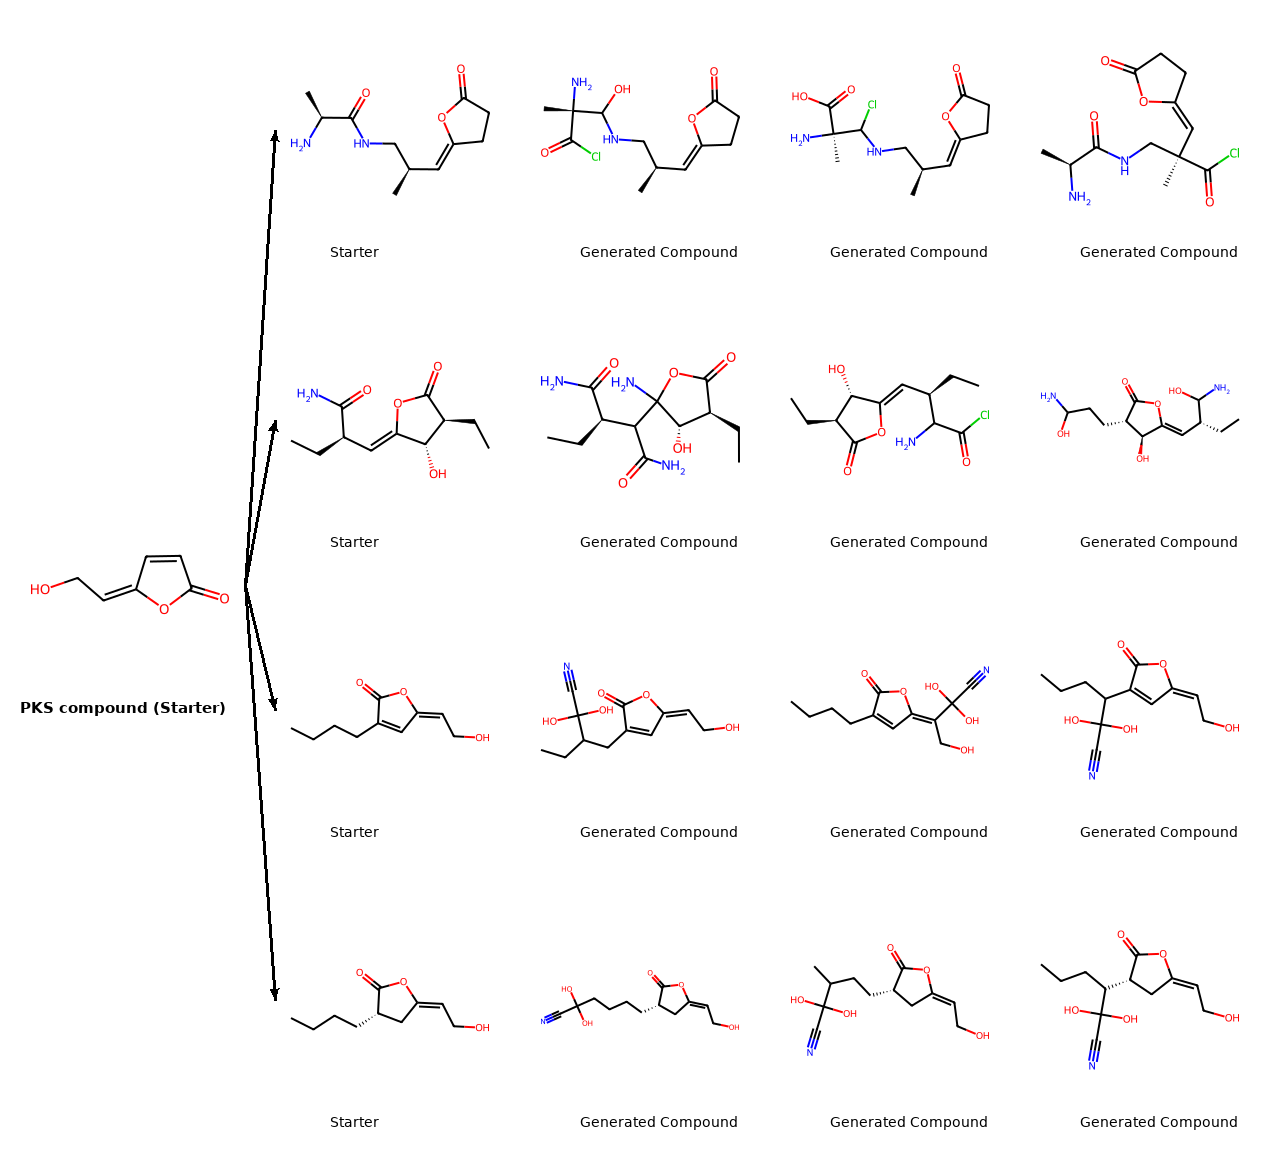

In [108]:
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import Draw, DataStructs, rdMolDescriptors
import math

basidalinPrecursorSmiles = "O=C1C=CC(=CCO)O1"
sourceDF = generatedCompoundsDF

# Minimum Tanimoto distance between any two selected starters.
# Raise this to force more diversity; lower it if too few groups qualify.
starterDiversityThreshold = 0.40


def toCanon(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol is not None else None


def morganFpForSmi(smi, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)


def isTooSimilarToSelected(candidateFp, selectedFps, threshold):
    """Returns True if candidateFp is within threshold of any already-selected starter."""
    for selectedFp in selectedFps:
        if DataStructs.TanimotoSimilarity(candidateFp, selectedFp) >= threshold:
            return True
    return False


def selectStarterGroups(sourceDF, numStarters=4, minCompoundsPerStarter=2,
                        maxCompoundsPerStarter=4, diversityThreshold=0.40):
    usedCanonSmiles  = set()
    selectedStarterFps = []
    selectedGroups   = []

    rootCanon = toCanon(basidalinPrecursorSmiles)
    if rootCanon is not None:
        usedCanonSmiles.add(rootCanon)

    # Most-populated directories first so richer starters compete first.
    candidateOrder = sorted(
        sourceDF.groupby("sourceDirectory"),
        key=lambda kv: kv[1]["Canonical_SMILES"].nunique(),
        reverse=True,
    )

    for sourceDirectory, group in candidateOrder:
        starterCandidates = group["starter_Canonical_SMILES"].dropna().unique()
        if len(starterCandidates) == 0:
            continue

        starterRaw   = starterCandidates[0]
        starterCanon = toCanon(starterRaw)
        if starterCanon is None or starterCanon in usedCanonSmiles:
            continue

        starterFp = morganFpForSmi(starterCanon)
        if starterFp is None:
            continue

        if isTooSimilarToSelected(starterFp, selectedStarterFps, diversityThreshold):
            print(f"  Skipping {sourceDirectory}: starter too similar to an already-selected starter "
                  f"(Tanimoto >= {diversityThreshold}).")
            continue

        candidateGenerated = []
        for rawSmi in group["Canonical_SMILES"].dropna().unique():
            c = toCanon(rawSmi)
            if c is None or c == starterCanon or c in usedCanonSmiles:
                continue
            candidateGenerated.append((c, rawSmi))

        if len(candidateGenerated) < minCompoundsPerStarter:
            print(f"  Skipping {sourceDirectory}: only {len(candidateGenerated)} qualifying "
                  f"generated compounds (minimum {minCompoundsPerStarter}).")
            continue

        chosenPairs   = candidateGenerated[:maxCompoundsPerStarter]
        chosenRawSmis = [raw for _, raw in chosenPairs]
        chosenCanons  = [c   for c, _  in chosenPairs]

        usedCanonSmiles.add(starterCanon)
        usedCanonSmiles.update(chosenCanons)
        selectedStarterFps.append(starterFp)

        selectedGroups.append({
            "sourceDirectory": sourceDirectory,
            "starterSmiles"  : starterRaw,
            "generatedSmiles": chosenRawSmis,
        })

        if len(selectedGroups) == numStarters:
            break

    return selectedGroups


selectedGroups = selectStarterGroups(
    sourceDF,
    numStarters=4,
    minCompoundsPerStarter=2,
    maxCompoundsPerStarter=3,
    diversityThreshold=starterDiversityThreshold,
)

print(f"\nSelected {len(selectedGroups)} starter groups "
      f"(diversity threshold: Tanimoto < {starterDiversityThreshold}):")
for g in selectedGroups:
    print(f"  Directory {g['sourceDirectory']}: {len(g['generatedSmiles'])} generated compounds")
    print(f"    Starter: {g['starterSmiles']}")
    for s in g["generatedSmiles"]:
        print(f"      -> {s}")

if not selectedGroups:
    print(f"\nWARNING: no starter groups met both minCompoundsPerStarter (2) and "
          f"diversity threshold ({starterDiversityThreshold}). "
          "Try lowering starterDiversityThreshold.")
elif len(selectedGroups) < 4:
    print(f"\nNote: only {len(selectedGroups)} qualifying groups found (requested 4). "
          f"Try lowering starterDiversityThreshold (currently {starterDiversityThreshold}) "
          "to admit more structurally similar starters.")


def smilesToImage(smiles, imgSize=(220, 220)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        img = Image.new("RGB", imgSize, "white")
        ImageDraw.Draw(img).text((10, imgSize[1] // 2), "Invalid SMILES", fill="red")
        return img
    return Draw.MolToImage(mol, size=imgSize)


def drawArrow(draw, x1, y1, x2, y2, color="black", width=3, headLen=12, headAngleDeg=20):
    draw.line([(x1, y1), (x2, y2)], fill=color, width=width)
    angle     = math.atan2(y2 - y1, x2 - x1)
    headAngle = math.radians(headAngleDeg)
    lx = x2 - headLen * math.cos(angle - headAngle)
    ly = y2 - headLen * math.sin(angle - headAngle)
    rx = x2 - headLen * math.cos(angle + headAngle)
    ry = y2 - headLen * math.sin(angle + headAngle)
    draw.polygon([(x2, y2), (lx, ly), (rx, ry)], fill=color)


def createStarterDoranetFigure(pksStarterSmi, selectedGroups, molSize=(220, 220)):
    padding, gap, labelHeight = 20, 30, 40
    molW, molH = molSize
    numRows = len(selectedGroups)

    maxGeneratedCols = max(len(g["generatedSmiles"]) for g in selectedGroups)
    totalDataCols    = 1 + maxGeneratedCols

    rowH        = molH + labelHeight
    gridHeight  = numRows * rowH + (numRows - 1) * gap
    frameWidth  = padding * 3 + molW + totalDataCols * molW + totalDataCols * gap
    frameHeight = padding * 2 + gridHeight

    frame = Image.new("RGB", (frameWidth, frameHeight), "white")
    draw  = ImageDraw.Draw(frame)

    try:
        font      = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
        titleFont = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 15)
    except (IOError, OSError):
        font      = ImageFont.load_default()
        titleFont = ImageFont.load_default()

    starterX      = padding
    starterY      = padding + (gridHeight - molH) // 2
    starterImg    = smilesToImage(pksStarterSmi, molSize)
    frame.paste(starterImg, (starterX, starterY))
    draw.text((starterX, starterY + molH + 4), "PKS compound (Starter)", fill="black", font=titleFont)

    starterRightX  = starterX + molW
    starterCenterY = starterY + molH // 2
    colX = [starterRightX + padding * 2 + c * (molW + gap) for c in range(totalDataCols)]

    for rowIdx, group in enumerate(selectedGroups):
        rowY = padding + rowIdx * (rowH + gap)

        starterColImg = smilesToImage(group["starterSmiles"], molSize)
        frame.paste(starterColImg, (colX[0], rowY))
        draw.text((colX[0] + 50, rowY + molH + 4), "Starter", fill="black", font=font)

        starterColCenterY = rowY + molH // 2
        drawArrow(draw, starterRightX + 5, starterCenterY, colX[0] - 5, starterColCenterY,
                  color="black", width=3, headLen=12, headAngleDeg=20)

        for genIdx, genSmi in enumerate(group["generatedSmiles"]):
            genX   = colX[genIdx + 1]
            genImg = smilesToImage(genSmi, molSize)
            frame.paste(genImg, (genX, rowY))
            draw.text((genX + 50, rowY + molH + 4), "Generated Compound", fill="black", font=font)

    return frame


if selectedGroups:
    publicationFigure = createStarterDoranetFigure(
        basidalinPrecursorSmiles, selectedGroups, molSize=(220, 220)
    )

    pngOutputPath = f"{fileNamePrefix}_PKS_Starter_DORAnet_compounds.png"
    pdfOutputPath = f"{fileNamePrefix}_PKS_Starter_DORAnet_compounds.pdf"

    publicationFigure.save(pngOutputPath, dpi=(300, 300))
    publicationFigure.save(pdfOutputPath, "PDF", resolution=300.0)

    print(f"Saved PNG : {pngOutputPath}")
    print(f"Saved PDF : {pdfOutputPath}")
    print(f"Figure size: {publicationFigure.width} x {publicationFigure.height} px")

    from IPython.display import display
    display(publicationFigure)

In [ ]:
nTargetsTotal   = 18
nTargetsPerRow  = 3
molCellW        = 420
molCellH        = 320
labelH          = 40
arrowZoneW      = 54
targetGap       = 10
dpi             = 600

white           = (255, 255, 255)
black           = (0,   0,   0  )
arrowColor      = (80,  80,  80 )

fontBoldPath    = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"


def loadFont(path, size):
    try:
        return ImageFont.truetype(path, size)
    except Exception:
        return ImageFont.load_default()


def renderMolToPil(mol, w, h):
    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(w, h)
        drawer.drawOptions().addStereoAnnotation = True
        drawer.drawOptions().padding = 0.12
        rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        return Image.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB")
    except Exception:
        from rdkit.Chem import Draw
        return Draw.MolToImage(mol, size=(w, h))


def selectDiverseIdxs(smilesList, nSelect, seed=42):
    fps, validIdxs = [], []
    for i, smi in enumerate(smilesList):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
            validIdxs.append(i)

    nSelect = min(nSelect, len(fps))

    def distFunc(i, j, fps=fps):
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

    picker      = MaxMinPicker()
    pickedLocal = list(picker.LazyPick(distFunc, len(fps), nSelect, seed=seed))
    return sorted([validIdxs[k] for k in pickedLocal])


def drawMolCell(mol, cellW, cellH, molH, label, fontBold):
    cell = Image.new("RGB", (cellW, cellH), white)
    ctx  = ImageDraw.Draw(cell)

    if mol is not None:
        molImg = renderMolToPil(mol, cellW - 16, molH - 8)
        cell.paste(molImg, (8, 4))

    bb  = ctx.textbbox((0, 0), label, font=fontBold)
    lW  = bb[2] - bb[0]
    ctx.text(((cellW - lW) // 2, molH + 10), label, fill=black, font=fontBold)
    return cell


def pasteArrow(canvas, x, y, length=34, color=arrowColor):
    d = ImageDraw.Draw(canvas)
    d.line([(x, y), (x + length, y)], fill=color, width=3)
    headL, headW = 10, 5
    d.polygon([
        (x + length,          y),
        (x + length - headL,  y - headW),
        (x + length - headL,  y + headW),
    ], fill=color)


def buildRowCanvas(starterMol, targetMols, fontBold):
    cellH = molCellH + labelH
    rowW  = (molCellW + arrowZoneW +
             nTargetsPerRow * molCellW +
             (nTargetsPerRow - 1) * targetGap)

    canvas      = Image.new("RGB", (rowW, cellH), white)
    starterCell = drawMolCell(starterMol, molCellW, cellH, molCellH, "Starter", fontBold)
    canvas.paste(starterCell, (0, 0))

    pasteArrow(canvas, x=molCellW + 6, y=cellH // 2, length=arrowZoneW - 16)

    for tIdx, targetMol in enumerate(targetMols):
        cellX      = molCellW + arrowZoneW + tIdx * (molCellW + targetGap)
        targetCell = drawMolCell(targetMol, molCellW, cellH, molCellH,
                                 "Generated Compound", fontBold)
        canvas.paste(targetCell, (cellX, 0))

    return canvas


print("Selecting structurally diverse compounds via MaxMinPicker...")
diverseIdxs = selectDiverseIdxs(
    generatedCompoundsDF["Canonical_SMILES"].tolist(),
    nTargetsTotal,
)
selectedDF = (
    generatedCompoundsDF
    .iloc[diverseIdxs]
    .copy()
    .reset_index(drop=True)
)
print(f"Selected {len(selectedDF)} compounds from {len(generatedCompoundsDF):,} total.")

rows = []
for starterSmi, grp in selectedDF.groupby("starter_Canonical_SMILES", sort=False):
    targets = grp["Canonical_SMILES"].tolist()
    for i in range(0, len(targets), nTargetsPerRow):
        batch = targets[i : i + nTargetsPerRow]
        while len(batch) < nTargetsPerRow:
            batch.append(None)
        rows.append({"starterSmi": starterSmi, "targets": batch})

fontBold    = loadFont(fontBoldPath, 16)
rowCanvases = []

for rowIdx, rowData in enumerate(rows):
    starterMol = Chem.MolFromSmiles(rowData["starterSmi"])
    targetMols = [
        Chem.MolFromSmiles(smi) if smi else None
        for smi in rowData["targets"]
    ]

    rowCanvas = buildRowCanvas(starterMol, targetMols, fontBold)
    rowCanvases.append(rowCanvas)

    pngPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.png"
    pdfPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.pdf"
    rowCanvas.save(pngPath, format="PNG", dpi=(dpi, dpi))
    rowCanvas.save(pdfPath, format="PDF", resolution=dpi)
    print(f"Row {rowIdx + 1:02d} saved: {pngPath}  |  {pdfPath}")

rowGap     = 14
rowCellH   = molCellH + labelH
fullW      = rowCanvases[0].width
fullH      = len(rowCanvases) * rowCellH + (len(rowCanvases) - 1) * rowGap
fullCanvas = Image.new("RGB", (fullW, fullH), white)

for i, rc in enumerate(rowCanvases):
    fullCanvas.paste(rc, (0, i * (rowCellH + rowGap)))

print(f"\n{len(rows)} row figures saved individually at {dpi} DPI.")
fullCanvas

### Print `pathway` level details

In [ ]:
def buildReactionIndex(reactionDF, canonHelperSet):
    molToRxnIdxs = defaultdict(list)
    rxnProducts  = {}

    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

        rxnProducts[idx] = frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    return molToRxnIdxs, rxnProducts


def countChainsToTargets(starterCanon, targetCanonSet, molToRxnIdxs,
                         rxnProducts, starterMols, maxDepth=3):
    scaffoldCache = {}

    def isScaffoldBearing(canonSmi):
        if canonSmi not in scaffoldCache:
            mol = Chem.MolFromSmiles(canonSmi)
            scaffoldCache[canonSmi] = (
                mol is not None and
                any(mol.HasSubstructMatch(starterMol) for _, starterMol in starterMols)
            )
        return scaffoldCache[canonSmi]

    def productsHaveScaffold(products):
        return any(isScaffoldBearing(m) for m in products)

    counts        = defaultdict(lambda: defaultdict(int))
    queue         = deque()
    statesVisited = 0

    for rxnIdx in molToRxnIdxs.get(starterCanon, []):
        products = rxnProducts[rxnIdx]
        chain    = (rxnIdx,)

        for target in products & targetCanonSet:
            counts[target][1] += 1

        if maxDepth > 1:
            queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        statesVisited += 1
        depth = len(chain)

        if depth >= maxDepth:
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = rxnProducts[rxnIdx]
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                for target in products & targetCanonSet:
                    counts[target][newDepth] += 1

                if newDepth < maxDepth:
                    newState = (newChain, products, visitedRxns | {rxnIdx})
                    if productsHaveScaffold(products):
                        queue.appendleft(newState)
                    else:
                        queue.append(newState)

    return counts, statesVisited


print("Building reaction index...")
molToRxnIdxs, rxnProducts = buildReactionIndex(reactionDF, canonHelperSet)
print(f"Indexed {len(molToRxnIdxs):,} unique non-helper reactant molecules.")
print(f"Indexed {len(rxnProducts):,} reactions.\n")

totalCompounds = len(generatedCompoundsDF)
print(f"Total compounds after deduplication (generatedCompoundsDF): {totalCompounds:,}\n")

summaryRecords     = []
perStarterSummary  = []

for starterSmi, group in generatedCompoundsDF.groupby("starter_Canonical_SMILES"):
    targetCanonSet  = set(group["Canonical_SMILES"].tolist())
    nTargets        = len(targetCanonSet)

    print(f"Starter : {starterSmi[:70]}")
    print(f"  Compounds from this starter  : {nTargets:,}")

    counts, statesVisited = countChainsToTargets(
        starterSmi,
        targetCanonSet,
        molToRxnIdxs,
        rxnProducts,
        starterMols = starterMols,
        maxDepth    = doranet_generations,
    )

    nWithPath    = sum(1 for t in targetCanonSet if counts.get(t))
    nWithoutPath = nTargets - nWithPath
    coverage     = nWithPath / nTargets * 100 if nTargets > 0 else 0.0

    print(f"  BFS states explored          : {statesVisited:,}")
    print(f"  With atlest one pathway              : {nWithPath:,}  ({coverage:.1f}%)")
    print(f"  With zero pathways           : {nWithoutPath:,}")
    print()

    perStarterSummary.append({
        "starter_Canonical_SMILES" : starterSmi,
        "total_compounds"          : nTargets,
        "compounds_with_pathway"   : nWithPath,
        "compounds_without_pathway": nWithoutPath,
        "pathway_coverage_pct"     : round(coverage, 2),
    })

    for _, row in group.iterrows():
        targetSmi    = row["Canonical_SMILES"]
        targetCounts = counts.get(targetSmi, {})
        n1 = targetCounts.get(1, 0)
        n2 = targetCounts.get(2, 0)
        n3 = targetCounts.get(3, 0)

        summaryRecords.append({
            "starter_Canonical_SMILES" : starterSmi,
            "Canonical_SMILES"         : targetSmi,
            "1step_pathways"           : n1,
            "2step_pathways"           : n2,
            "3step_pathways"           : n3,
            "total_pathways"           : n1 + n2 + n3,
        })

pathSummaryDF = (
    pd.DataFrame(summaryRecords)
    .sort_values(
        ["starter_Canonical_SMILES", "total_pathways"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

perStarterSummaryDF = pd.DataFrame(perStarterSummary)

nZero    = (pathSummaryDF["total_pathways"] == 0).sum()
nNonZero = (pathSummaryDF["total_pathways"] >  0).sum()


if nZero > 0:
    print(f"\n  Note: {nZero} zero-pathway compounds persist after exhaustive BFS.")
    print(f"  This indicates a canonicalization mismatch between")
    print(f"  buildStarterDerivedSet and countChainsToTargets.")

pathSummaryDF

### Visualize `starter → product` reaction pathways from the network

In [ ]:
molSize      = (260, 200)
sepWidth     = 80
stepBannerH  = 32
stepGap      = 10
depthWords   = {1: "One-Step", 2: "Two-Step", 3: "Three-Step"}


def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

fontSep   = loadFont(52)
fontLabel = loadFont(18)
fontStep  = loadFont(17)


def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")


def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bb    = draw.textbbox((0, 0), text, font=font)
        textW = bb[2] - bb[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)


def getMolLabel(canon, canonStarterSet, genuineProductSet, isLastStep, isProductSide):
    if not isProductSide:
        return "Starter" if canon in canonStarterSet else "Reactant"
    if isProductSide and canon in genuineProductSet and isLastStep:
        return "Target Compound"
    return "Product"


def makeLabeledMolImage(smi, label):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg = rdkitImageToPil(Draw.MolToImage(mol, size=molSize))
    banner = Image.new("RGB", (molImg.width, 32), "#f0f0f0")
    centeredText(ImageDraw.Draw(banner), label, molImg.width, 6, fontLabel, "#222222")
    out = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    out.paste(molImg, (0, 0))
    out.paste(banner, (0, molImg.height))
    return out


def makeSeparatorImage(text, height, width=80):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bb     = draw.textbbox((0, 0), text, font=fontSep)
        tw, th = bb[2] - bb[0], bb[3] - bb[1]
    except Exception:
        tw, th = 30, 50
    draw.text(((width - tw) // 2, (height - th) // 2), text, fill="#222222", font=fontSep)
    return img


def renderReactionStep(rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                       canonHelperSet, isLastStep, stepLabel):
    row = reactionDF.loc[rxnIdx]

    reactantSmis = splitMoleculeString(row["reactants"])
    productSmis  = splitMoleculeString(row["products"])

    reactantSmis = (
        [s for s in reactantSmis if canonSmiles(s) in canonStarterSet] +
        [s for s in reactantSmis if canonSmiles(s) not in canonStarterSet]
    )
    productSmis = (
        [s for s in productSmis if canonSmiles(s) in genuineProductSet] +
        [s for s in productSmis if canonSmiles(s) not in genuineProductSet]
    )

    reactantImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=False),
            ) for s in reactantSmis
        ] if img is not None
    ]
    productImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=True),
            ) for s in productSmis
        ] if img is not None
    ]

    if not reactantImgs or not productImgs:
        return None

    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 14
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))

    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    rxnRow = Image.new("RGB", (totalW, maxH), "white")
    x      = 0
    for part in parts:
        rxnRow.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap

    stepBanner = Image.new("RGB", (totalW, stepBannerH), "#dce8f5")
    centeredText(ImageDraw.Draw(stepBanner), stepLabel, totalW,
                 (stepBannerH - 20) // 2, fontStep, "#003366")

    panel = Image.new("RGB", (totalW, stepBannerH + rxnRow.height), "white")
    panel.paste(stepBanner, (0, 0))
    panel.paste(rxnRow,     (0, stepBannerH))
    return panel


def stackStepPanels(panels):
    if not panels:
        return None
    w      = max(p.width for p in panels)
    totalH = sum(p.height for p in panels) + stepGap * (len(panels) - 1)
    canvas = Image.new("RGB", (w, totalH), "white")
    y = 0
    for p in panels:
        canvas.paste(p, (0, y))
        y += p.height + stepGap
    return canvas


def findPathwayChains(reactionDF, canonStarterSet, genuineProductSet,
                      canonHelperSet, maxDepth=3, maxPerDepth=3):
    """
    Exhaustive BFS with no frontier cap. Safe because DORAnet ran a bounded
    3-step expansion, so the reaction network is finite and the BFS is
    guaranteed to terminate.
    """
    molToRxnIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

    def getNonHelperProducts(rxnIdx):
        row = reactionDF.loc[rxnIdx]
        return frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    pathways = {d: [] for d in range(1, maxDepth + 1)}
    queue    = deque()

    for starterCanon in canonStarterSet:
        for rxnIdx in molToRxnIdxs.get(starterCanon, []):
            products = getNonHelperProducts(rxnIdx)
            chain    = (rxnIdx,)
            if products & genuineProductSet and len(pathways[1]) < maxPerDepth:
                pathways[1].append(chain)
            if maxDepth > 1:
                queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        depth = len(chain)

        if depth >= maxDepth:
            continue

        if all(len(pathways[d]) >= maxPerDepth for d in range(depth + 1, maxDepth + 1)):
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = getNonHelperProducts(rxnIdx)
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                if products & genuineProductSet and len(pathways[newDepth]) < maxPerDepth:
                    pathways[newDepth].append(newChain)

                if newDepth < maxDepth:
                    queue.append((newChain, products, visitedRxns | {rxnIdx}))

    return pathways


genuineProductSet = set(generatedCompoundsDF["Canonical_SMILES"].dropna().unique())

print("Searching for 1-step, 2-step, and 3-step pathway chains...")
pathwaysByDepth = findPathwayChains(
    reactionDF,
    canonStarterSet,
    genuineProductSet,
    canonHelperSet,
)
for d, chains in pathwaysByDepth.items():
    print(f"  {d}-step pathways found: {len(chains)}")

savedFiles = []

for depth in range(1, 4):
    chains = pathwaysByDepth[depth]
    if not chains:
        print(f"\nNo {depth}-step pathways found.")
        continue

    for pIdx, chain in enumerate(chains):
        stepPanels = []
        totalSteps = len(chain)

        for stepIdx, rxnIdx in enumerate(chain):
            isLastStep = (stepIdx == totalSteps - 1)
            stepLabel  = (
                f"{depthWords[totalSteps]} Pathway  "
                f"(Step {stepIdx + 1} of {totalSteps})"
            )
            panel = renderReactionStep(
                rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                canonHelperSet, isLastStep, stepLabel,
            )
            if panel is not None:
                stepPanels.append(panel)

        pathwayImg = stackStepPanels(stepPanels)
        if pathwayImg is None:
            continue

        baseName = f"{fileNamePrefix}_step{depth}_pathway{pIdx + 1}"
        pngPath  = f"{baseName}.png"
        pdfPath  = f"{baseName}.pdf"

        pathwayImg.save(pngPath, format="PNG", dpi=(600, 600))
        pathwayImg.save(pdfPath, format="PDF", resolution=600)
        savedFiles.append((pngPath, pdfPath))

        print(f"Saved: {pngPath}  |  {pdfPath}")
        display(pathwayImg)

print(f"\nTotal pathway figures saved: {len(savedFiles)}")

### Use DORA-XGB to get feasibility score

We run this script from the command line since it contains a large number of reactions
and running it from a Jupyter cell can oversubscribe CPU cores due to the nature of
the XGBoost algorithm. Run it as:

`python runDORAXGB.py doraxgb_config.yaml`

### Keep only `high feasible` reactions

In [ ]:
reactionDF_DORAXGB = pd.read_csv("reactionDF_wDORAXGBfeasibility.csv")
reactionDF_DORAXGB

In [ ]:
feasibilityLabels = [
    "feasibilityLabel_rule1",
    "feasibilityLabel_rule2",
    "feasibilityLabel_rule3",
    "feasibilityLabel_rule4",
]
targetValue = 1

for lbl in feasibilityLabels:
    if lbl not in reactionDF_DORAXGB.columns:
        raise KeyError(f"Column '{lbl}' not found in reactionDF_DORAXGB")

results = {}
for feasibilityLabel in feasibilityLabels:
    high_df = reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ].sort_values(by=feasibilityLabel, ascending=False).reset_index(drop=True)
    results[feasibilityLabel] = {"count_high": len(high_df), "df": high_df}

print(f"Target value considered as highly feasible: {targetValue}")
for lbl in feasibilityLabels:
    print(f"{lbl}: {results[lbl]['count_high']} highly feasible reactions")

best_rule = max(feasibilityLabels, key=lambda l: results[l]["count_high"])
bestRuleScoreCol = best_rule.replace("Label", "Score")   # needed for pathway scoring below
reactionDF_DORAXGB_highFeasibility = results[best_rule]["df"]

print(f"\nChosen feasibility label: {best_rule} == {targetValue}")
print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")

In [ ]:
def canonicalizeSMILES(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None


def extractSmilesWithSource(df, columnName):
    """Like extractSmilesSet, but tracks which SourceStarterNum(s) each
    extracted SMILES actually came from, using each ROW's own SourceStarterNum.
    reactionDF_DORAXGB_highFeasibility has one row per reaction, each already
    correctly tagged with the starter directory it was read from (cell 10) --
    this preserves that instead of collapsing every molecule to one global value.
    """
    sourceMap = {}  # canonical SMILES -> set of SourceStarterNum
    for _, row in df[[columnName, "SourceStarterNum"]].dropna(subset=[columnName, "SourceStarterNum"]).iterrows():
        entry = row[columnName]
        starterNum = row["SourceStarterNum"]

        if isinstance(entry, (list, tuple)):
            rawMols = [s.strip() for s in entry if s and s.strip()]
        elif isinstance(entry, str):
            rawMols = []
            for chunk in entry.split(";"):
                chunk = chunk.strip()
                for mol in chunk.split("."):
                    mol = mol.strip()
                    if mol:
                        rawMols.append(mol)
        else:
            continue

        for rawSmi in rawMols:
            canonSmi = canonicalizeSMILES(rawSmi)
            if canonSmi is None:
                continue
            sourceMap.setdefault(canonSmi, set()).add(starterNum)

    return sourceMap


if "SourceStarterNum" not in reactionDF_DORAXGB_highFeasibility.columns:
    raise KeyError("'SourceStarterNum' not found in reactionDF_DORAXGB_highFeasibility")

# --- Extract SMILES, keeping every SourceStarterNum each one is actually
# associated with -- a molecule can legitimately be generated under more
# than one starter, and this preserves that instead of picking just one. ---
reactantSourceMap = extractSmilesWithSource(reactionDF_DORAXGB_highFeasibility, "reactants")
productSourceMap  = extractSmilesWithSource(reactionDF_DORAXGB_highFeasibility, "products")

reactantSet = set(reactantSourceMap.keys())
productSet  = set(productSourceMap.keys())
starterSet  = {c for s in user_starters if (c := canonicalizeSMILES(s)) is not None}
allMolecules = reactantSet | productSet | starterSet

# user_starters is a flat set combined across all directories (cell 8), with
# no per-job mapping of its own -- attribute each starter to whichever job(s)
# it actually shows up as a reactant in, which is its real source.
starterSourceMap = {smi: reactantSourceMap.get(smi, set()) for smi in starterSet}


def allSourceStarterNums(smiles):
    return reactantSourceMap.get(smiles, set()) | productSourceMap.get(smiles, set()) | starterSourceMap.get(smiles, set())


# --- Print summary stats ---
print(f"Unique canonical reactant SMILES : {len(reactantSet)}")
print(f"Unique canonical product  SMILES : {len(productSet)}")
print(f"Unique canonical starter  SMILES : {len(starterSet)}")
print(f"Total unique canonical    SMILES : {len(allMolecules)}")
print(f"  (reactants only)               : {len(reactantSet - productSet - starterSet)}")
print(f"  (products only)                : {len(productSet - reactantSet - starterSet)}")
print(f"  (both reactant & product)      : {len(reactantSet & productSet)}")
allStarterNumsSeen = sorted({n for smi in allMolecules for n in allSourceStarterNums(smi)})

# --- Build rows: ONE ROW PER (SMILES, SourceStarterNum) PAIR ---
# This is an explode, not a collapse: a molecule generated under multiple
# starters gets one row per starter, so groupby("SourceStarterNum") downstream
# (e.g. the PKS/RetroTide figure) sees it correctly under every starter it
# actually came from, instead of only the first one alphabetically.
rows = []
for smiles in starterSet:
    isReactant = smiles in reactantSet
    isProduct  = smiles in productSet
    for starterNum in (allSourceStarterNums(smiles) or {None}):
        rows.append({
            "SMILES"           : smiles,
            "Is_reactant"      : isReactant,
            "Is_product"       : isProduct,
            "Is_Starter"       : True,
            "SourceDirectory"  : fileNamePrefix,
            "SourceStarterNum" : starterNum,
        })

for smiles in allMolecules - starterSet:
    isReactant = smiles in reactantSet
    isProduct  = smiles in productSet
    isStarter  = isReactant and not isProduct
    for starterNum in (allSourceStarterNums(smiles) or {None}):
        rows.append({
            "SMILES"           : smiles,
            "Is_reactant"      : isReactant,
            "Is_product"       : isProduct,
            "Is_Starter"       : isStarter,
            "SourceDirectory"  : fileNamePrefix,
            "SourceStarterNum" : starterNum,
        })

reactionDF_DORAXGB_highFeasibility_uniqueMolecules = (
    pd.DataFrame(rows)
    .drop_duplicates(subset=["SMILES", "SourceStarterNum"])  # NOT "SMILES" alone -- see note below
    .reset_index(drop=True)
)

print(f"\nFinal dataframe shape: {reactionDF_DORAXGB_highFeasibility_uniqueMolecules.shape}")
print(f"Unique SMILES: {reactionDF_DORAXGB_highFeasibility_uniqueMolecules['SMILES'].nunique()}")
print(f"Unique SourceStarterNum groups: {reactionDF_DORAXGB_highFeasibility_uniqueMolecules['SourceStarterNum'].nunique()}")
reactionDF_DORAXGB_highFeasibility_uniqueMolecules

### Remove HELPERS and Deduplicate

In [ ]:
# Step 1: Remove helpers
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = reactionDF_DORAXGB_highFeasibility_uniqueMolecules[
    ~reactionDF_DORAXGB_highFeasibility_uniqueMolecules['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = (
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules) -
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)
)
helpersKeptPercent = (
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers) /
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules)
) * 100

print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Already deduplicated — just confirm no duplicates exist
duplicateCount = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['SMILES'].duplicated().sum()
print(f"\nStep 2 - Duplicate SMILES found: {duplicateCount}")

if duplicateCount > 0:
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = (
        reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
        .drop_duplicates(subset='SMILES', keep='first')
        .reset_index(drop=True)
    )
    print(f"  Deduplicated to: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} molecules")
else:
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = (
        reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
        .reset_index(drop=True)
    )

# Step 4: Save
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers.to_csv(
    f"{fileNamePrefix}_uniqueMolecules.csv", index=False, encoding="utf-8"
)
print(f"\nSaved to: {fileNamePrefix}_uniqueMolecules.csv")

reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers

In [ ]:
def countAtoms(smiles: str) -> dict:
    """Count C, O, N, S atoms in a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {'C_count': np.nan, 'O_count': np.nan, 'N_count': np.nan, 'S_count': np.nan}

    # Add explicit hydrogens if you also want H count
    atomCounts = {'C': 0, 'O': 0, 'N': 0, 'S': 0}
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in atomCounts:
            atomCounts[symbol] += 1

    return {
        'C_count': atomCounts['C'],
        'O_count': atomCounts['O'],
        'N_count': atomCounts['N'],
        'S_count': atomCounts['S']
    }


# Apply to each SMILES
atomCountsDF = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['SMILES'].apply(
    lambda s: pd.Series(countAtoms(s))
)

# Concatenate with original dataframe
uniqueMolecules_molCONS = pd.concat(
    [reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers, atomCountsDF],
    axis=1
)

uniqueMolecules_molCONS

### Generate .gif file

In [ ]:
import itertools
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image as IPImage

sourceDF = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers

MOL_SIZE       = (220, 220)
ROWS_PER_FRAME = 3
GENS_PER_ROW   = 3
MAX_FRAMES     = 100

# ── Step 1: Separate molecules ────────────────────────────────────────────────

starterSmiles   = sourceDF[sourceDF['Is_Starter'] == True]['SMILES'].tolist()
generatedSmiles = sourceDF[sourceDF['Is_Starter'] == False]['SMILES'].tolist()
starterSmilesSet = set(starterSmiles)

print(f"Source directory    : {sourceDF['SourceDirectory'].unique().tolist()}")
print(f"Starter molecules   : {len(starterSmiles)}")
print(f"Generated molecules : {len(generatedSmiles)}")

# ── Step 2: Build row data ────────────────────────────────────────────────────
# Column 1 cycles through starters then generated molecules
# Columns 2-4 show consecutive chunks of 3 generated molecules

col1Cycle = itertools.cycle(starterSmiles + generatedSmiles)

rowData = []
for genStart in range(0, len(generatedSmiles), GENS_PER_ROW):
    genChunk = generatedSmiles[genStart:genStart + GENS_PER_ROW]
    rowData.append((next(col1Cycle), genChunk, genStart))

framesGrouped = [
    rowData[i:i + ROWS_PER_FRAME]
    for i in range(0, len(rowData), ROWS_PER_FRAME)
]
print(f"Total frames available : {len(framesGrouped)}")

# ── Step 3: Sample frames before rendering ────────────────────────────────────

if len(framesGrouped) > MAX_FRAMES:
    sampleIndices = np.linspace(0, len(framesGrouped) - 1, MAX_FRAMES, dtype=int)
    framesSampled = [framesGrouped[i] for i in sampleIndices]
else:
    framesSampled = framesGrouped

print(f"Frames to render       : {len(framesSampled)}")

# ── Step 4: Pre-render only column 1 images needed for sampled frames ─────────

neededCol1Smiles = {row[0] for frame in framesSampled for row in frame}
col1ImageCache   = {}

def smiles_to_image(smiles, img_size=MOL_SIZE):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        img  = Image.new('RGB', img_size, 'white')
        draw = ImageDraw.Draw(img)
        draw.text((10, img_size[1] // 2), "Invalid SMILES", fill='red')
        return img
    return Draw.MolToImage(mol, size=img_size)

for smi in neededCol1Smiles:
    col1ImageCache[smi] = smiles_to_image(smi)

print(f"Column 1 images pre-rendered : {len(col1ImageCache)}")

# ── Step 5: Frame rendering ───────────────────────────────────────────────────

def create_frame(rows, col1ImageCache, mol_size=MOL_SIZE):
    """
    Create one GIF frame with ROWS_PER_FRAME rows.
    Each row layout: [col1 molecule] --> [gen1] [gen2] [gen3]

    rows           : list of (col1_smiles, [gen_smiles, ...], start_index)
    col1ImageCache : dict of {smiles: PIL.Image} — pre-rendered column 1 images
    """
    padding      = 15
    arrow_width  = 60
    label_height = 22
    row_height   = mol_size[1] + label_height + padding * 2
    frame_height = row_height * len(rows)

    col1_x        = padding
    arrow_x_start = col1_x + mol_size[0] + padding
    arrow_x_end   = arrow_x_start + arrow_width
    gen_x_start   = arrow_x_end + padding
    gen_col_width = mol_size[0] + padding
    frame_width   = gen_x_start + GENS_PER_ROW * gen_col_width + padding

    frame = Image.new('RGB', (frame_width, frame_height), 'white')
    draw  = ImageDraw.Draw(frame)

    try:
        font       = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 12)
        title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 13)
    except (IOError, OSError):
        font = title_font = ImageFont.load_default()

    for row_idx, (col1_smi, gen_smiles_list, start_index) in enumerate(rows):
        mol_y   = row_idx * row_height + padding
        arrow_y = mol_y + mol_size[1] // 2

        # Column 1: pre-rendered image
        frame.paste(col1ImageCache[col1_smi], (col1_x, mol_y))
        col1_label = "Starter PKS protein" if col1_smi in starterSmilesSet else "PKS protein"
        draw.text(
            (col1_x, mol_y + mol_size[1] + 3),
            col1_label,
            fill='blue', font=title_font
        )

        # Arrow
        draw.line(
            [(arrow_x_start, arrow_y), (arrow_x_end, arrow_y)],
            fill='black', width=3
        )
        draw.polygon([
            (arrow_x_end,      arrow_y - 8),
            (arrow_x_end + 12, arrow_y),
            (arrow_x_end,      arrow_y + 8),
        ], fill='black')

        # Columns 2-4: generated molecules rendered on the fly
        for gen_idx, gen_smi in enumerate(gen_smiles_list[:GENS_PER_ROW]):
            gen_x = gen_x_start + gen_idx * gen_col_width
            frame.paste(smiles_to_image(gen_smi, mol_size), (gen_x, mol_y))
            draw.text(
                (gen_x, mol_y + mol_size[1] + 3),
                f"DORAnet Compound #{start_index + gen_idx + 1}",
                fill='green', font=font
            )

        # Row separator
        if row_idx < len(rows) - 1:
            sep_y = (row_idx + 1) * row_height
            draw.line([(0, sep_y), (frame_width, sep_y)], fill='lightgray', width=1)

    return frame

# ── Step 6: Render sampled frames ─────────────────────────────────────────────

allFrameImages = []
for frame_idx, frameRows in enumerate(framesSampled):
    allFrameImages.append(create_frame(frameRows, col1ImageCache))
    if (frame_idx + 1) % 25 == 0:
        print(f"Rendered frame {frame_idx + 1}/{len(framesSampled)}")

# ── Step 7: Save GIF ──────────────────────────────────────────────────────────

gifOutputPath = f"{fileNamePrefix}_highFeasibility.gif"
allFrameImages[0].save(
    gifOutputPath,
    save_all=True,
    append_images=allFrameImages[1:],
    duration=3000,
    loop=0
)
print(f"Saved GIF    : {gifOutputPath}")
print(f"Total frames : {len(allFrameImages)}")

display(IPImage(filename=gifOutputPath))